In [57]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# PART B : DATASET PREPARATION

In [58]:
df = pd.read_csv("RealEstate_HousePrice_Dataset.csv")

In [59]:
df.head()

,house_id,area_sqft,bedrooms,bathrooms,location_score,age_years,distance_city_km,lot_size_sqft,has_garage,has_pool,renovation_years_ago,house_price_inr
0,100001,1973,5,4,7.6,23,11.9,5220,1,0,0,40275084
1,100002,1560,3,3,6.3,13,15.8,3882,1,0,13,26812029
2,100003,2071,4,3,5.8,9,21.1,4488,0,0,9,29315677
3,100004,2640,5,3,7.7,12,7.9,3614,1,1,4,47712959
4,100005,1498,3,3,3.8,15,24.0,2663,0,0,15,17724566


In [60]:
print(df.shape)

(4200, 12)


In [61]:
print(df.columns)

Index(['house_id', 'area_sqft', 'bedrooms', 'bathrooms', 'location_score',
       'age_years', 'distance_city_km', 'lot_size_sqft', 'has_garage',
       'has_pool', 'renovation_years_ago', 'house_price_inr'],
      dtype='str')


In [62]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4200 entries, 0 to 4199
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   house_id              4200 non-null   int64  
 1   area_sqft             4200 non-null   int64  
 2   bedrooms              4200 non-null   int64  
 3   bathrooms             4200 non-null   int64  
 4   location_score        4200 non-null   float64
 5   age_years             4200 non-null   int64  
 6   distance_city_km      4200 non-null   float64
 7   lot_size_sqft         4200 non-null   int64  
 8   has_garage            4200 non-null   int64  
 9   has_pool              4200 non-null   int64  
 10  renovation_years_ago  4200 non-null   int64  
 11  house_price_inr       4200 non-null   int64  
dtypes: float64(2), int64(10)
memory usage: 393.9 KB


In [63]:
df.isnull().sum()

house_id                0
area_sqft               0
bedrooms                0
bathrooms               0
location_score          0
age_years               0
distance_city_km        0
lot_size_sqft           0
has_garage              0
has_pool                0
renovation_years_ago    0
house_price_inr         0
dtype: int64

In [64]:
df.duplicated().sum()

np.int64(0)

In [65]:
df.describe()

,house_id,area_sqft,bedrooms,bathrooms,location_score,age_years,distance_city_km,lot_size_sqft,has_garage,has_pool,renovation_years_ago,house_price_inr
count,4200.000000,4200.000000,4200.000000,4200.000000,4200.000000,4200.000000,4200.000000,4200.000000,4200.000000,4200.000000,4200.000000,4.200000e+03
mean,102100.500000,1667.357381,3.696667,2.827381,5.611429,23.829524,18.186167,3366.329048,0.642381,0.096190,7.955714,2.364189e+07
std,1212.579894,630.336132,1.574199,1.153585,2.140880,13.945663,8.674549,1658.230565,0.479356,0.294887,7.316766,1.239279e+07
min,100001.000000,450.000000,1.000000,1.000000,1.000000,1.000000,1.000000,800.000000,0.000000,0.000000,0.000000,8.000000e+05
25%,101050.750000,1226.750000,3.000000,2.000000,4.000000,13.000000,11.800000,2122.500000,0.000000,0.000000,2.000000,1.425969e+07
50%,102100.500000,1660.000000,4.000000,3.000000,5.700000,21.000000,17.800000,3188.000000,1.000000,0.000000,6.000000,2.214500e+07
75%,103150.250000,2084.250000,5.000000,4.000000,7.300000,32.000000,24.200000,4364.250000,1.000000,0.000000,12.000000,3.096090e+07
max,104200.000000,4202.000000,7.000000,6.000000,10.000000,80.000000,47.600000,12938.000000,1.000000,1.000000,50.000000,7.611172e+07


In [66]:
print(df.isnull().sum())

missing_percent = (df.isnull().sum()/len(df))*100

missing_df = pd.DataFrame({
    'Missing Values':df.isnull().sum(),
    'Percentage':missing_percent
})

print(missing_df)

house_id                0
area_sqft               0
bedrooms                0
bathrooms               0
location_score          0
age_years               0
distance_city_km        0
lot_size_sqft           0
has_garage              0
has_pool                0
renovation_years_ago    0
house_price_inr         0
dtype: int64
                      Missing Values  Percentage
house_id                           0         0.0
area_sqft                          0         0.0
bedrooms                           0         0.0
bathrooms                          0         0.0
location_score                     0         0.0
age_years                          0         0.0
distance_city_km                   0         0.0
lot_size_sqft                      0         0.0
has_garage                         0         0.0
has_pool                           0         0.0
renovation_years_ago               0         0.0
house_price_inr                    0         0.0


# Univariate Analysis

In [67]:
num_cols = df.select_dtypes(include=np.number).columns

print(num_cols)

Index(['house_id', 'area_sqft', 'bedrooms', 'bathrooms', 'location_score',
       'age_years', 'distance_city_km', 'lot_size_sqft', 'has_garage',
       'has_pool', 'renovation_years_ago', 'house_price_inr'],
      dtype='str')


Histograms

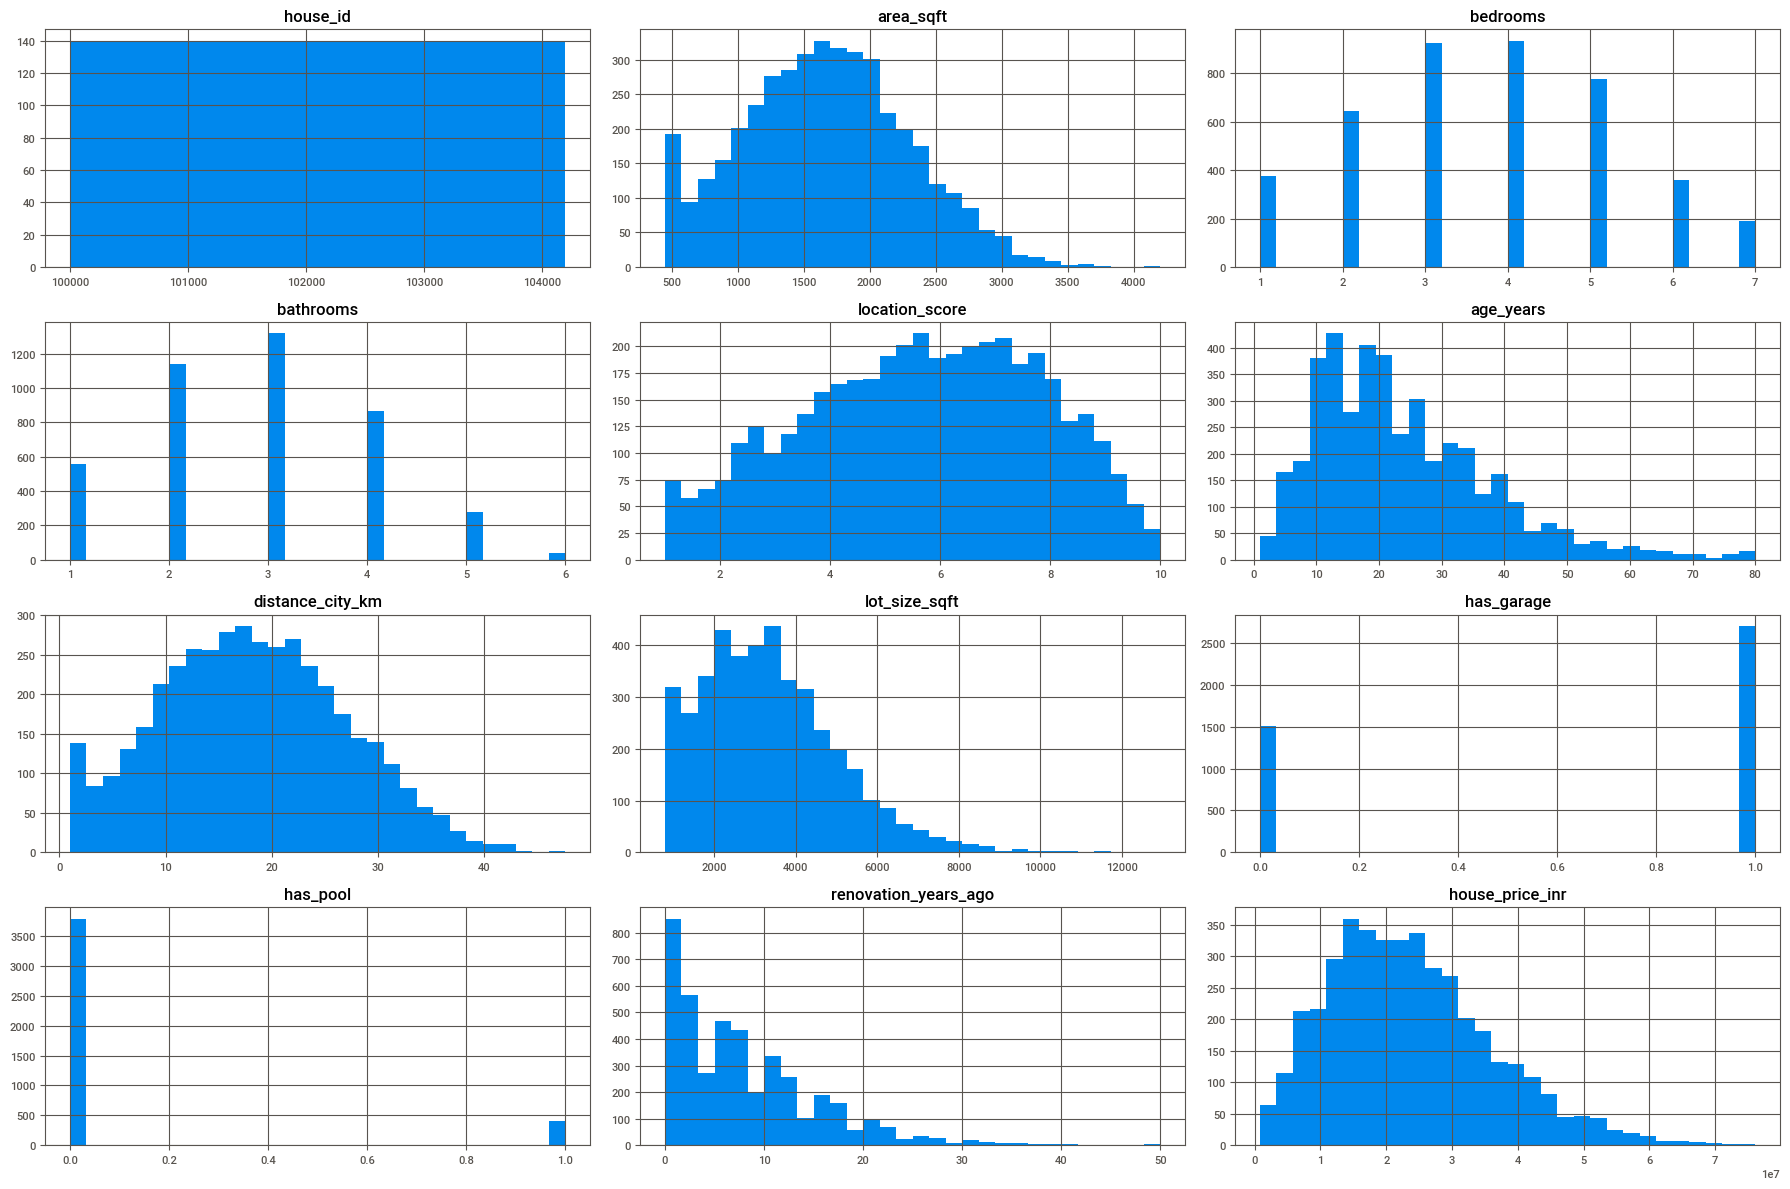

In [68]:
df[num_cols].hist(
    figsize=(18,12),
    bins=30
)

plt.tight_layout()
plt.show()

Distribution Plot

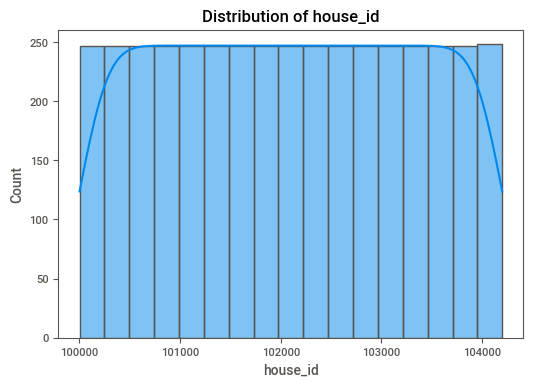

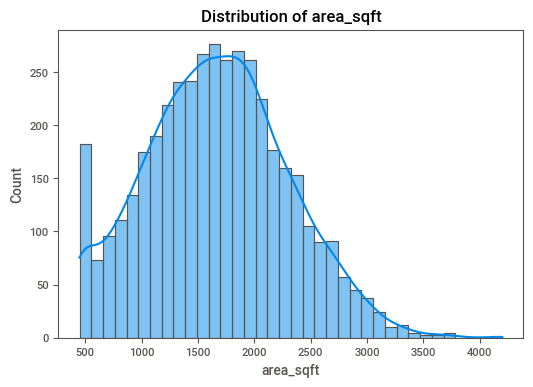

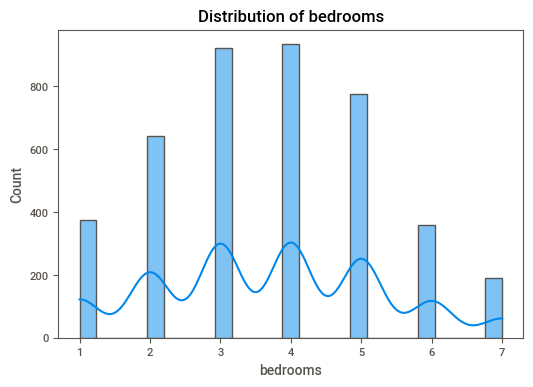

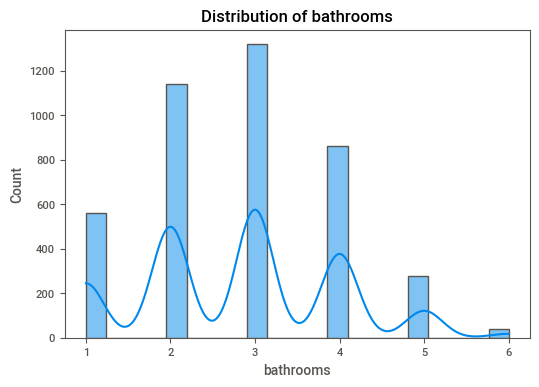

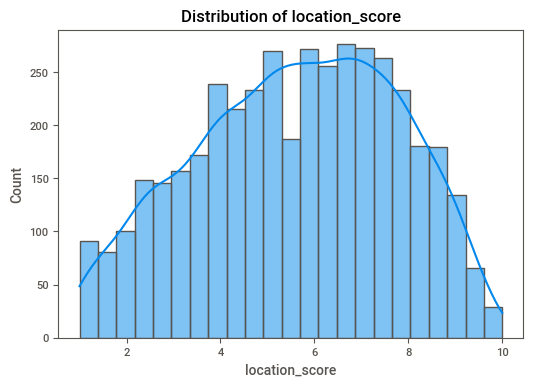

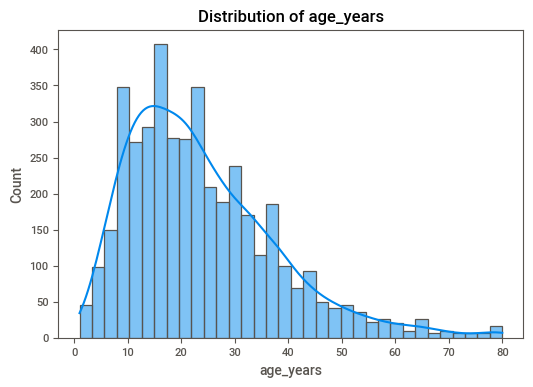

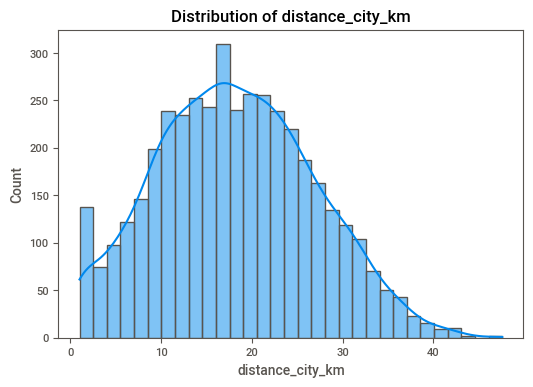

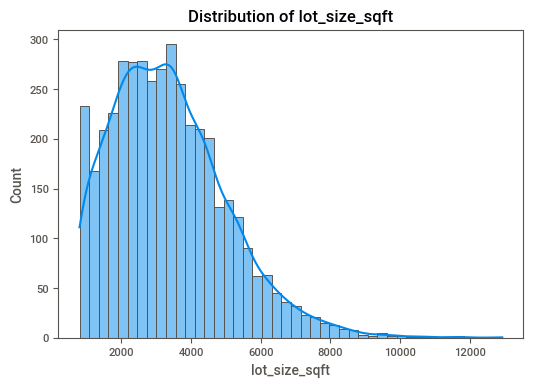

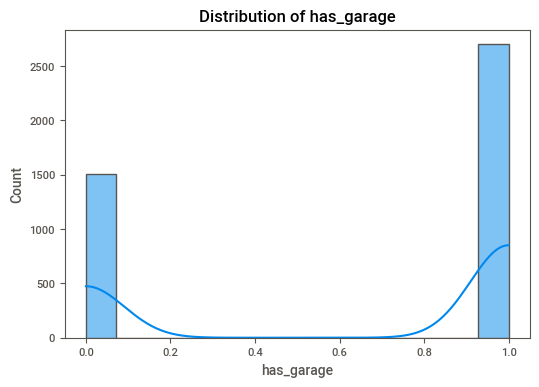

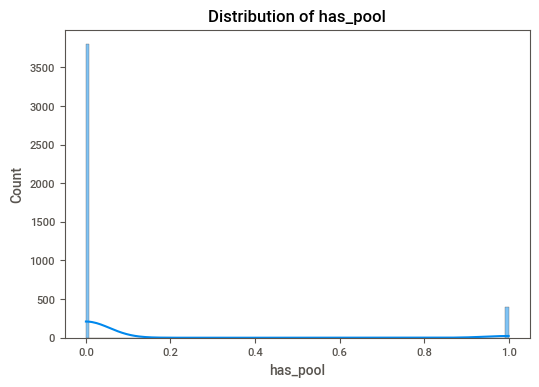

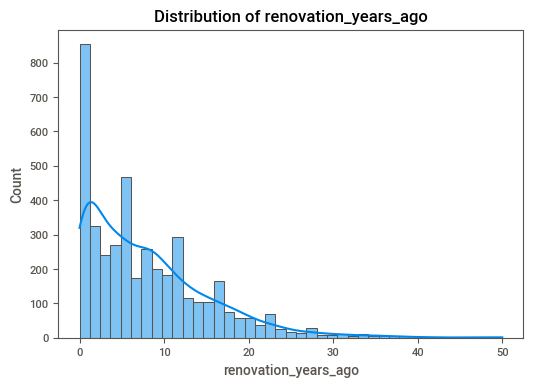

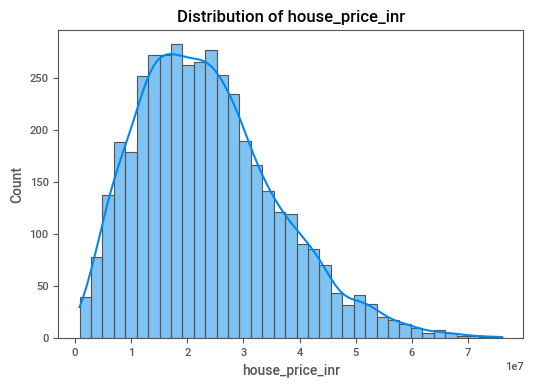

In [69]:
for col in num_cols:

    plt.figure(figsize=(6,4))

    sns.histplot(
        df[col],
        kde=True
    )

    plt.title(f"Distribution of {col}")
    plt.show()

Outlier Treatment using IQR

In [70]:
# Create a copy
df_clean = df.copy()

# Continuous numerical columns
outlier_cols = [
    'area_sqft',
    'location_score',
    'age_years',
    'distance_city_km',
    'lot_size_sqft',
    'renovation_years_ago',
    'house_price_inr'
]

for col in outlier_cols:

    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df_clean = df_clean[
        (df_clean[col] >= lower_bound) &
        (df_clean[col] <= upper_bound)
    ]

print("Original Shape :", df.shape)
print("After Outlier Removal :", df_clean.shape)

print("Rows Removed :", df.shape[0] - df_clean.shape[0])

Original Shape : (4200, 12)
After Outlier Removal : (3895, 12)
Rows Removed : 305


# Skewness Analysis

In [71]:
skewness = df_clean[num_cols].skew()

print(skewness.sort_values(ascending=False))

has_pool                2.738426
renovation_years_ago    0.848964
age_years               0.715865
lot_size_sqft           0.467948
house_price_inr         0.460885
bathrooms               0.226989
bedrooms                0.131897
distance_city_km        0.128229
area_sqft               0.038639
house_id               -0.002553
location_score         -0.178257
has_garage             -0.558371
dtype: float64


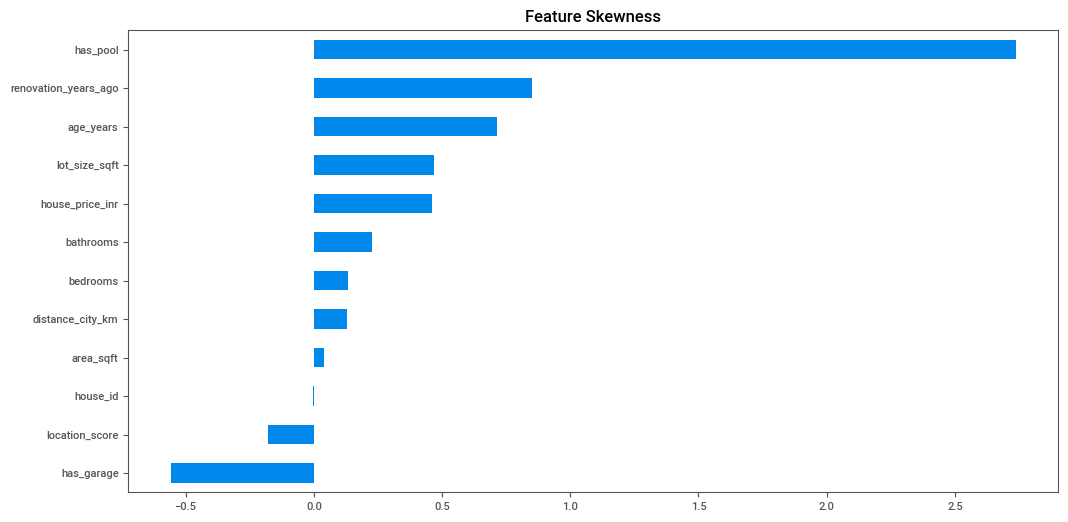

In [72]:
plt.figure(figsize=(12,6))

skewness.sort_values().plot(kind='barh')

plt.title("Feature Skewness")

plt.show()

# Correlation Analysis

In [73]:
corr_matrix = df_clean.corr(numeric_only=True)

corr_matrix

,house_id,area_sqft,bedrooms,bathrooms,location_score,age_years,distance_city_km,lot_size_sqft,has_garage,has_pool,renovation_years_ago,house_price_inr
house_id,1.000000,-0.027986,-0.008951,-0.005650,-0.011799,-0.007026,0.009536,-0.038940,0.030554,0.024299,-0.015734,-0.031642
area_sqft,-0.027986,1.000000,0.837931,0.655626,-0.031372,-0.021673,0.017027,0.739085,0.211071,-0.025449,0.000890,0.736502
bedrooms,-0.008951,0.837931,1.000000,0.774471,-0.040928,-0.015500,0.027933,0.621511,0.250936,-0.017264,0.001759,0.619272
bathrooms,-0.005650,0.655626,0.774471,1.000000,-0.016196,-0.015699,0.002804,0.478435,0.179449,-0.015329,-0.006854,0.500194
location_score,-0.011799,-0.031372,-0.040928,-0.016196,1.000000,-0.012741,-0.738329,-0.033834,-0.002972,0.187956,-0.010660,0.588475
age_years,-0.007026,-0.021673,-0.015500,-0.015699,-0.012741,1.000000,-0.004745,-0.018767,0.006870,-0.008104,0.190977,-0.091868
distance_city_km,0.009536,0.017027,0.027933,0.002804,-0.738329,-0.004745,1.000000,0.019310,0.002706,-0.139799,0.007464,-0.470269
lot_size_sqft,-0.038940,0.739085,0.621511,0.478435,-0.033834,-0.018767,0.019310,1.000000,0.168282,-0.024993,0.002095,0.547644
has_garage,0.030554,0.211071,0.250936,0.179449,-0.002972,0.006870,0.002706,0.168282,1.000000,0.012830,0.021881,0.166039
has_pool,0.024299,-0.025449,-0.017264,-0.015329,0.187956,-0.008104,-0.139799,-0.024993,0.012830,1.000000,-0.009758,0.108905


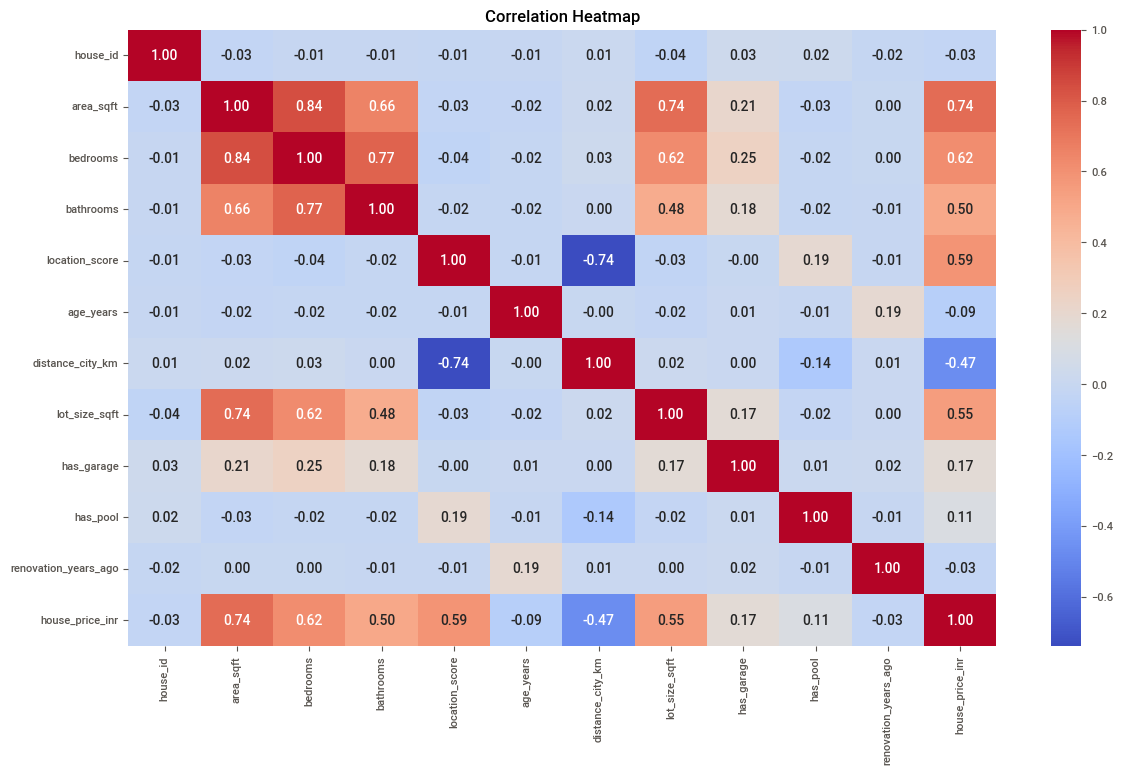

In [74]:
plt.figure(figsize=(14,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Heatmap")

plt.show()

# Correlation with Target

In [75]:
target_corr = corr_matrix['house_price_inr'].sort_values(
    ascending=False
)

print(target_corr)

house_price_inr         1.000000
area_sqft               0.736502
bedrooms                0.619272
location_score          0.588475
lot_size_sqft           0.547644
bathrooms               0.500194
has_garage              0.166039
has_pool                0.108905
renovation_years_ago   -0.027279
house_id               -0.031642
age_years              -0.091868
distance_city_km       -0.470269
Name: house_price_inr, dtype: float64


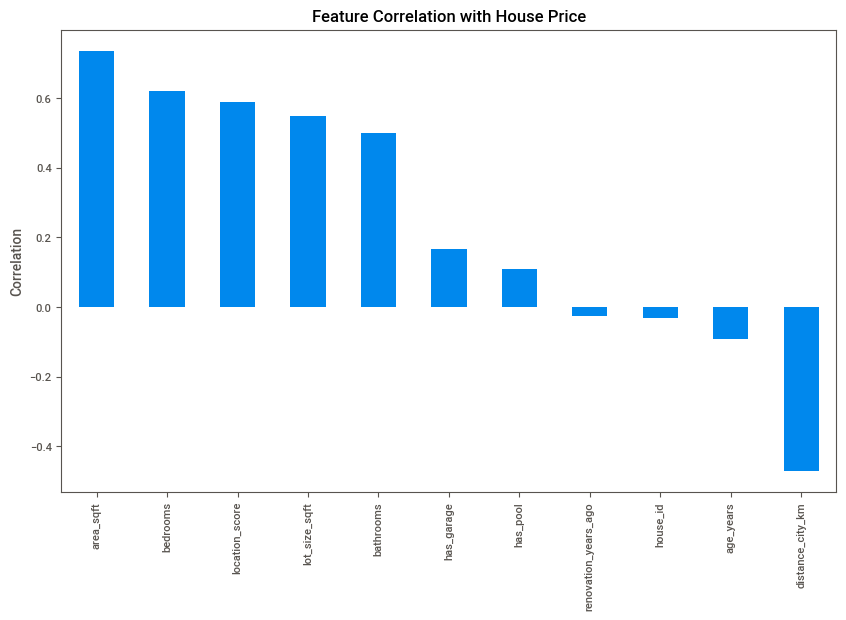

In [76]:
plt.figure(figsize=(10,6))

target_corr.drop('house_price_inr').plot(
    kind='bar'
)

plt.title("Feature Correlation with House Price")

plt.ylabel("Correlation")

plt.show()

# Pairplot

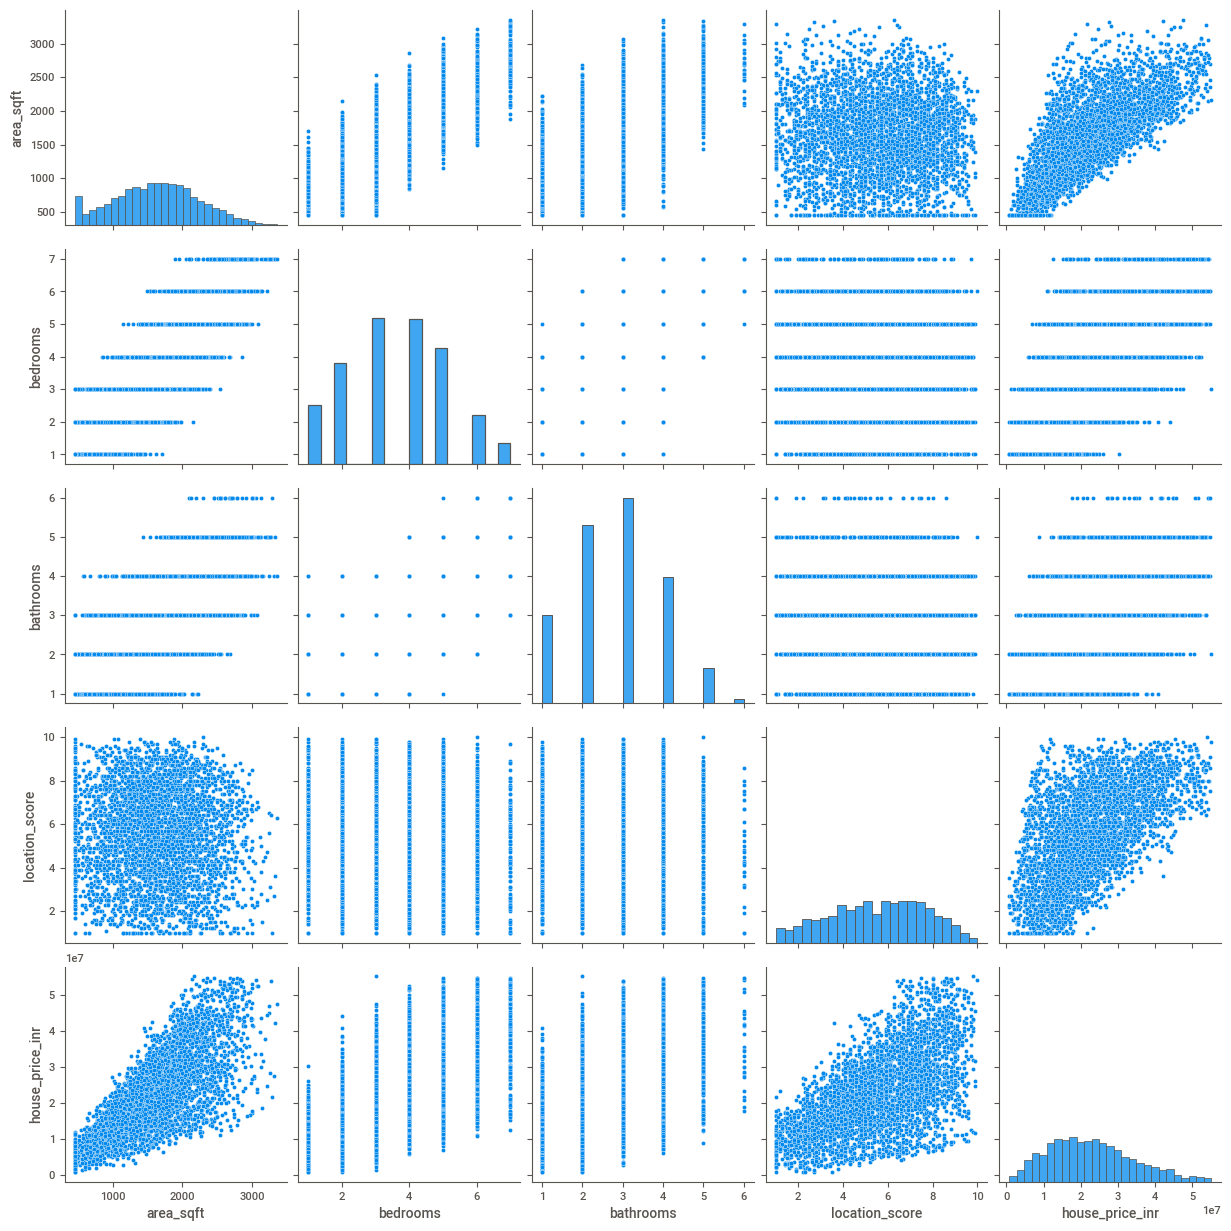

In [77]:
important_cols = [
    'area_sqft',
    'bedrooms',
    'bathrooms',
    'location_score',
    'house_price_inr'
]

sns.pairplot(df_clean[important_cols])

plt.show()

# Feature vs Target Analysis

Area vs Price

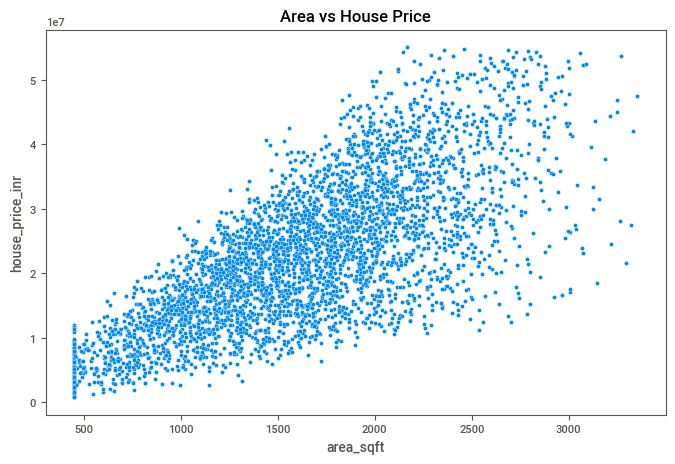

In [78]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x='area_sqft',
    y='house_price_inr',
    data=df_clean
)

plt.title("Area vs House Price")

plt.show()

Bedrooms vs Price

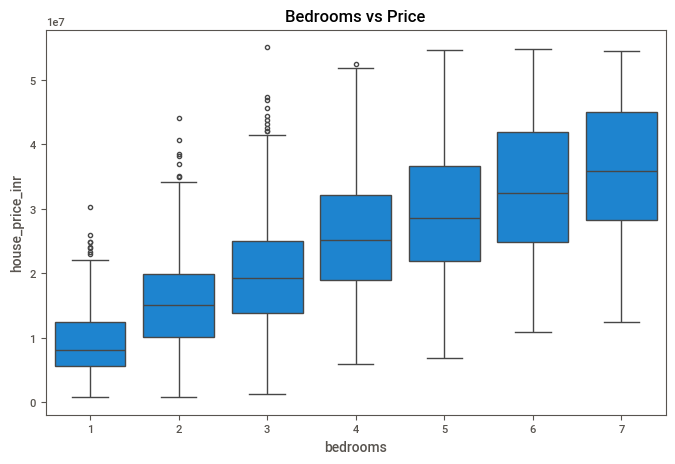

In [79]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='bedrooms',
    y='house_price_inr',
    data=df_clean
)

plt.title("Bedrooms vs Price")

plt.show()

# Feature Engineering

House Age Category

In [80]:
df_clean['Age_Category'] = pd.cut(
    df_clean['age_years'],
    bins=[0,5,15,30,100],
    labels=['New','Moderate','Old','Very Old']
)

print(df_clean['Age_Category'].value_counts())

Age_Category
Old         1643
Moderate    1163
Very Old     953
New          136
Name: count, dtype: int64


# Feature Scaling

In [81]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scale_cols = [
    'area_sqft',
    'lot_size_sqft',
    'distance_city_km',
    'location_score'
]

df_clean[scale_cols] = scaler.fit_transform(
    df_clean[scale_cols]
)

df_clean.head()

,house_id,area_sqft,bedrooms,bathrooms,location_score,age_years,distance_city_km,lot_size_sqft,has_garage,has_pool,renovation_years_ago,house_price_inr,Age_Category
0,100001,0.578399,5,4,0.961063,23,-0.747136,1.307592,1,0,0,40275084,Old
1,100002,-0.113009,3,3,0.349967,13,-0.294042,0.419953,1,0,13,26812029,Moderate
2,100003,0.742462,4,3,0.114930,9,0.321701,0.821978,0,0,9,29315677,Moderate
3,100004,1.695031,5,3,1.008070,12,-1.211848,0.242160,1,1,4,47712959,Moderate
4,100005,-0.216804,3,3,-0.825218,15,0.658617,-0.388740,0,0,15,17724566,Moderate


In [82]:
! pip install sweetviz

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [83]:
import pandas as pd
import sweetviz as sv

# Load Dataset
df = pd.read_csv("RealEstate_HousePrice_Dataset.csv")

# Create Sweetviz Report
report = sv.analyze(df)

# Generate HTML Report
report.show_html(
    "HousePrice_Sweetviz_Report.html",
    open_browser=True
)

Done! Use 'show' commands to display/save.   |██████████| [100%]   00:01 -> (00:00 left)

Report HousePrice_Sweetviz_Report.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.
